In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [7]:
df=pd.read_csv('/content/drive/MyDrive/ab_data.csv' , encoding='latin-1')

In [11]:
print("Shape :", df.shape )
print("col stats :" , df.describe())
print(" /////first 5 rows/////// " )
df.head()
print("data type :" , df.dtypes)


Shape : (294478, 5)
col stats :              user_id      converted
count  294478.000000  294478.000000
mean   787974.124733       0.119659
std     91210.823776       0.324563
min    630000.000000       0.000000
25%    709032.250000       0.000000
50%    787933.500000       0.000000
75%    866911.750000       0.000000
max    945999.000000       1.000000


,user_id,timestamp,group,landing_page,converted
0,851104,2017-01-21 22:11:48.556739,control,old_page,0
1,804228,2017-01-12 08:01:45.159739,control,old_page,0
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0
4,864975,2017-01-21 01:52:26.210827,control,old_page,1


In [14]:
df.isnull().sum()

,0
user_id,0
timestamp,0
group,0
landing_page,0
converted,0


In [20]:
print(f"\ngroup counts : { df['group'].value_counts()}")

print(f"\nconversion rate : {df.groupby('group')['converted'].mean() }")



group counts : group
treatment    147276
control      147202
Name: count, dtype: int64

conversion rate : group
control      0.120399
treatment    0.118920
Name: converted, dtype: float64


In [22]:
print(f"\n Mismatched rows: {len(df[((df['group']=='treatment') & (df['landing_page']=='old_page')) | ((df['group']=='control') & (df['landing_page']=='new_page'))])}")


 Mismatched rows: 3893


In [23]:
#flag mismatch rows
mismatch = df[
    ((df['group'] == 'treatment') & (df['landing_page'] == 'old_page')) |
    ((df['group'] == 'control') & (df['landing_page'] == 'new_page'))
]
print(f"Mismatched rows: {len(mismatch)} ({len(mismatch)/len(df)*100:.2f}% of data)")

Mismatched rows: 3893 (1.32% of data)


In [24]:
#Remove mismatches
df_clean = df[
    ((df['group'] == 'treatment') & (df['landing_page'] == 'new_page')) |
    ((df['group'] == 'control') & (df['landing_page'] == 'old_page'))
].copy()

In [25]:
#remove duplicate users
df_clean = df_clean.drop_duplicates(subset='user_id', keep='first')
print(f"Rows after cleaning: {len(df_clean)}")

Rows after cleaning: 290584


In [26]:
#SRM check
control_n = len(df_clean[df_clean['group'] == 'control'])
treatment_n = len(df_clean[df_clean['group'] == 'treatment'])
total = control_n + treatment_n
expected = total / 2

chi2_stat = ((control_n - expected)**2 / expected) + ((treatment_n - expected)**2 / expected)
p_srm = 1 - stats.chi2.cdf(chi2_stat, df=1)

print(f"\nSRM Check:")
print(f"Control: {control_n} | Treatment: {treatment_n}")
print(f"Chi2: {chi2_stat:.4f} | p-value: {p_srm:.4f}")
print(f"SRM detected: {'YES ' if p_srm < 0.05 else 'NO'}")


SRM Check:
Control: 145274 | Treatment: 145310
Chi2: 0.0045 | p-value: 0.9468
SRM detected: NO


Control:   17489/145274 = 0.1204 (12.04%)
Treatment: 17264/145310 = 0.1188 (11.88%)
Lift: -1.31%

Z-statistic: -1.3109
P-value: 0.1899
Result: Not significant
95% CI for difference: [-0.0039, 0.0008]

Statistical Power: 0.2587


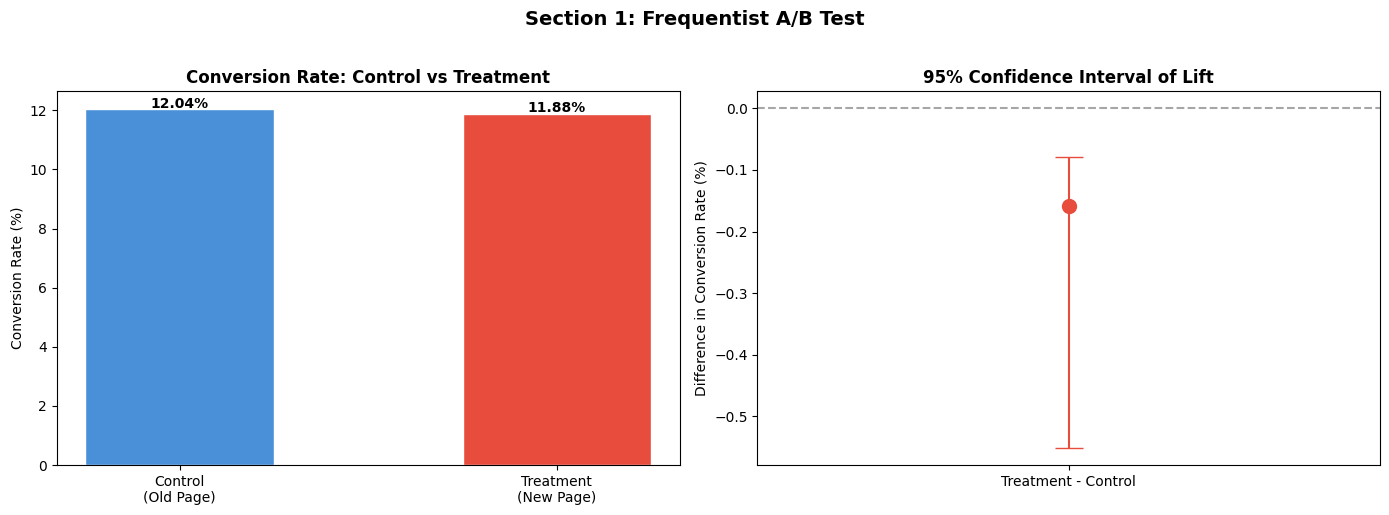

Plot saved!


In [27]:
#  Frequentist A/B Test
from statsmodels.stats.proportion import proportions_ztest, proportion_effectsize
from statsmodels.stats.power import NormalIndPower

# Conversion stats
control = df_clean[df_clean['group'] == 'control']
treatment = df_clean[df_clean['group'] == 'treatment']

ctrl_conv = control['converted'].sum()
trt_conv = treatment['converted'].sum()
ctrl_n = len(control)
trt_n = len(treatment)

ctrl_rate = ctrl_conv / ctrl_n
trt_rate = trt_conv / trt_n

print(f"Control:   {ctrl_conv}/{ctrl_n} = {ctrl_rate:.4f} ({ctrl_rate*100:.2f}%)")
print(f"Treatment: {trt_conv}/{trt_n} = {trt_rate:.4f} ({trt_rate*100:.2f}%)")
print(f"Lift: {((trt_rate - ctrl_rate)/ctrl_rate)*100:.2f}%")

# Z-test
count = np.array([trt_conv, ctrl_conv])
nobs = np.array([trt_n, ctrl_n])
z_stat, p_value = proportions_ztest(count, nobs)
print(f"\nZ-statistic: {z_stat:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"Result: {'Significant ' if p_value < 0.05 else 'Not significant'}")

# Confidence interval
se = np.sqrt(ctrl_rate*(1-ctrl_rate)/ctrl_n + trt_rate*(1-trt_rate)/trt_n)
ci_low = (trt_rate - ctrl_rate) - 1.96*se
ci_high = (trt_rate - ctrl_rate) + 1.96*se
print(f"95% CI for difference: [{ci_low:.4f}, {ci_high:.4f}]")

# Power analysis
effect = proportion_effectsize(ctrl_rate, trt_rate)
power = NormalIndPower().solve_power(effect_size=abs(effect), nobs1=ctrl_n, alpha=0.05)
print(f"\nStatistical Power: {power:.4f}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
axes[0].bar(['Control\n(Old Page)', 'Treatment\n(New Page)'],
            [ctrl_rate*100, trt_rate*100],
            color=['#4A90D9', '#E74C3C'], width=0.5, edgecolor='white')
axes[0].set_ylabel('Conversion Rate (%)')
axes[0].set_title('Conversion Rate: Control vs Treatment', fontweight='bold')
for i, v in enumerate([ctrl_rate*100, trt_rate*100]):
    axes[0].text(i, v + 0.05, f'{v:.2f}%', ha='center', fontweight='bold')

# CI plot
axes[1].axhline(0, color='gray', linestyle='--', alpha=0.7, label='No difference')
axes[1].errorbar(['Treatment - Control'], [(trt_rate-ctrl_rate)*100],
                 yerr=[[abs(ci_low*100)], [ci_high*100]],
                 fmt='o', color='#E74C3C', capsize=10, markersize=10)
axes[1].set_ylabel('Difference in Conversion Rate (%)')
axes[1].set_title('95% Confidence Interval of Lift', fontweight='bold')

plt.suptitle('Section 1: Frequentist A/B Test', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('section1_frequentist.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved!")

P(Treatment > Control): 0.0936 (9.4%)
Expected lift (Bayesian): -0.1584%

Control 95% Credible Interval:   [0.1187, 0.1221]
Treatment 95% Credible Interval: [0.1171, 0.1205]


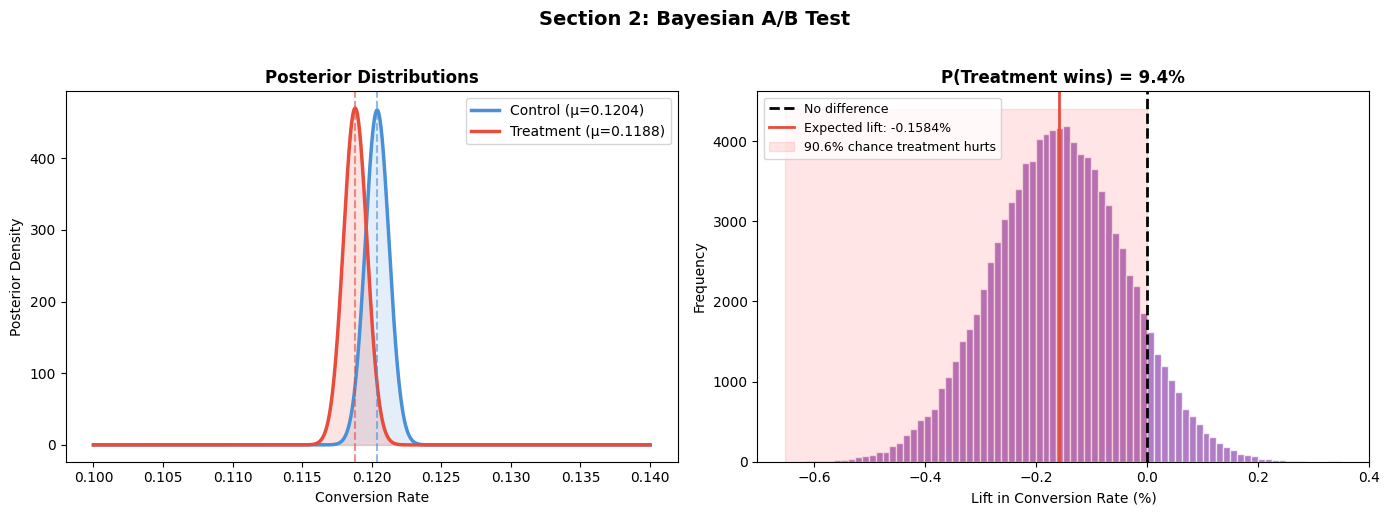

In [29]:
#  Bayesian A/B Test
from scipy.stats import beta as beta_dist

# Prior: Beta(1,1) = uniform / uninformative
alpha_prior, beta_prior = 1, 1

# Posterior parameters
alpha_ctrl = alpha_prior + ctrl_conv
beta_ctrl = beta_prior + (ctrl_n - ctrl_conv)

alpha_trt = alpha_prior + trt_conv
beta_trt = beta_prior + (trt_n - trt_conv)

# Monte Carlo sampling
np.random.seed(42)
samples = 100_000
ctrl_samples = beta_dist.rvs(alpha_ctrl, beta_ctrl, size=samples)
trt_samples = beta_dist.rvs(alpha_trt, beta_trt, size=samples)

prob_trt_wins = (trt_samples > ctrl_samples).mean()
expected_lift = (trt_samples - ctrl_samples).mean()

print(f"P(Treatment > Control): {prob_trt_wins:.4f} ({prob_trt_wins*100:.1f}%)")
print(f"Expected lift (Bayesian): {expected_lift*100:.4f}%")

# 95% Credible intervals
ctrl_ci = np.percentile(ctrl_samples, [2.5, 97.5])
trt_ci = np.percentile(trt_samples, [2.5, 97.5])
print(f"\nControl 95% Credible Interval:   [{ctrl_ci[0]:.4f}, {ctrl_ci[1]:.4f}]")
print(f"Treatment 95% Credible Interval: [{trt_ci[0]:.4f}, {trt_ci[1]:.4f}]")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Posterior distributions
x = np.linspace(0.10, 0.14, 1000)
axes[0].plot(x, beta_dist.pdf(x, alpha_ctrl, beta_ctrl),
             color='#4A90D9', lw=2.5, label=f'Control (μ={ctrl_rate:.4f})')
axes[0].plot(x, beta_dist.pdf(x, alpha_trt, beta_trt),
             color='#E74C3C', lw=2.5, label=f'Treatment (μ={trt_rate:.4f})')
axes[0].fill_between(x, beta_dist.pdf(x, alpha_ctrl, beta_ctrl), alpha=0.15, color='#4A90D9')
axes[0].fill_between(x, beta_dist.pdf(x, alpha_trt, beta_trt), alpha=0.15, color='#E74C3C')
axes[0].set_xlabel('Conversion Rate')
axes[0].set_ylabel('Posterior Density')
axes[0].set_title('Posterior Distributions', fontweight='bold')
axes[0].legend()
axes[0].axvline(ctrl_rate, color='#4A90D9', linestyle='--', alpha=0.6)
axes[0].axvline(trt_rate, color='#E74C3C', linestyle='--', alpha=0.6)

# Distribution of lift
lift_samples = (trt_samples - ctrl_samples) * 100
axes[1].hist(lift_samples, bins=80, color='#8E44AD', alpha=0.7, edgecolor='white')
axes[1].axvline(0, color='black', linestyle='--', lw=2, label='No difference')
axes[1].axvline(expected_lift*100, color='#E74C3C', linestyle='-', lw=2,
                label=f'Expected lift: {expected_lift*100:.4f}%')
neg_pct = (lift_samples < 0).mean() * 100
axes[1].fill_betweenx([0, axes[1].get_ylim()[1] if axes[1].get_ylim()[1] > 0 else 5000],
                       lift_samples.min(), 0, alpha=0.1, color='red', label=f'{neg_pct:.1f}% chance treatment hurts')
axes[1].set_xlabel('Lift in Conversion Rate (%)')
axes[1].set_ylabel('Frequency')
axes[1].set_title(f'P(Treatment wins) = {prob_trt_wins*100:.1f}%', fontweight='bold')
axes[1].legend(fontsize=9)

plt.suptitle('Section 2: Bayesian A/B Test', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('section2_bayesian.png', dpi=150, bbox_inches='tight')
plt.show()


Daily lift summary:
First 5 days avg lift: -0.2225%
Last 5 days avg lift:  -0.1974%
Trend direction: Stable / No novelty effect 


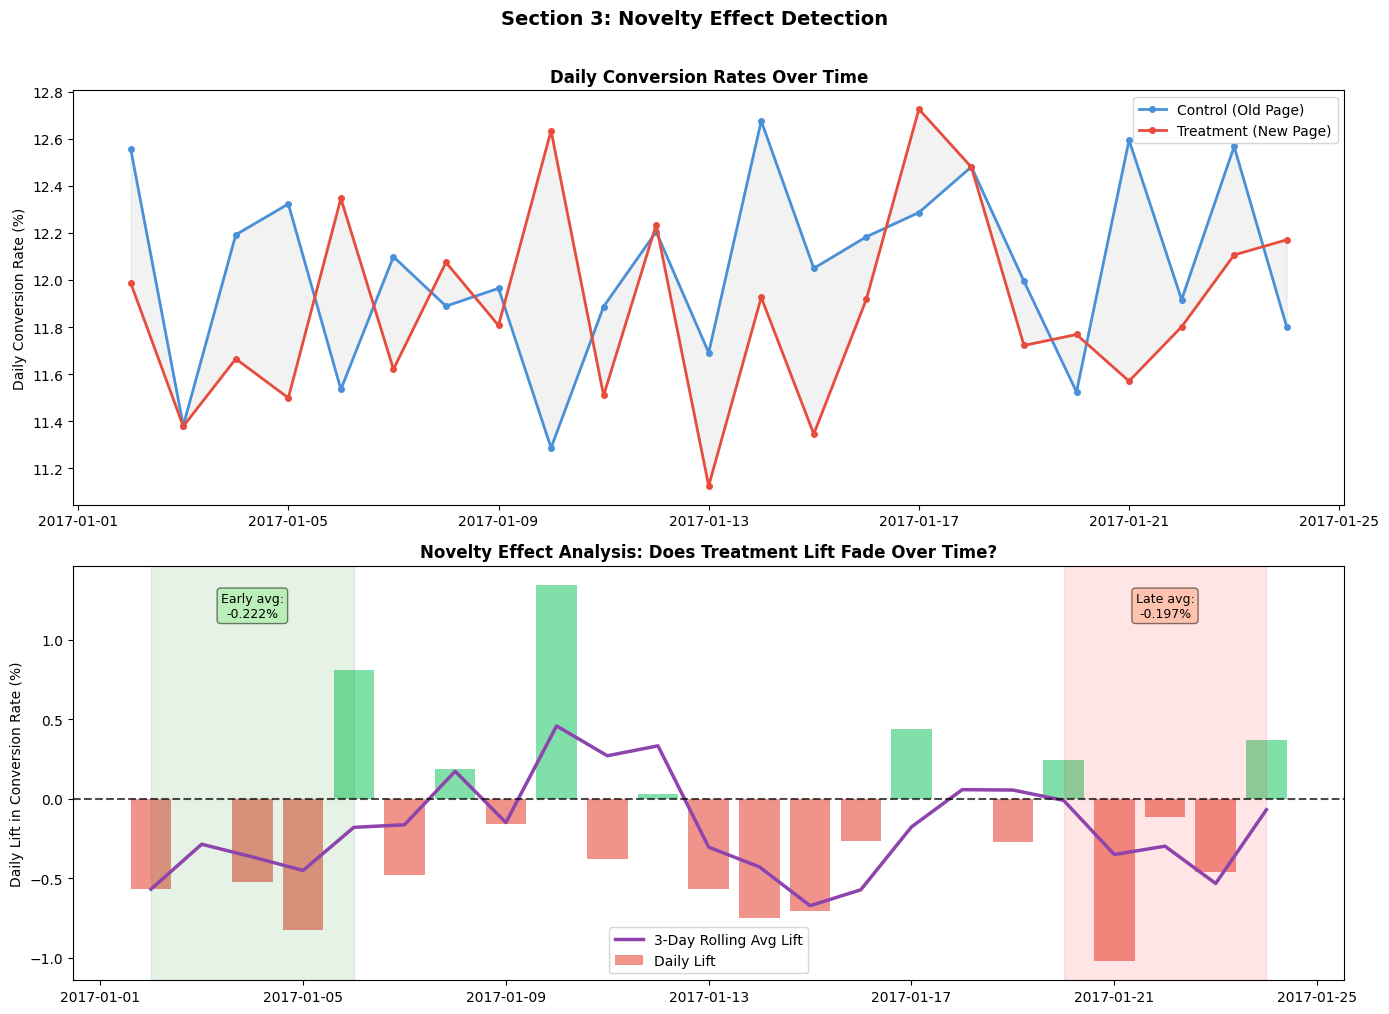

In [31]:
# Novelty Effect Detection
df_clean['timestamp'] = pd.to_datetime(df_clean['timestamp'])
df_clean['date'] = df_clean['timestamp'].dt.date

# Daily conversion rates per group
daily = df_clean.groupby(['date', 'group']).agg(
    conversions=('converted', 'sum'),
    users=('converted', 'count')
).reset_index()
daily['conversion_rate'] = daily['conversions'] / daily['users']

ctrl_daily = daily[daily['group'] == 'control'].sort_values('date')
trt_daily = daily[daily['group'] == 'treatment'].sort_values('date')

# Daily lift
merged = ctrl_daily.merge(trt_daily, on='date', suffixes=('_ctrl', '_trt'))
merged['daily_lift'] = (merged['conversion_rate_trt'] - merged['conversion_rate_ctrl']) * 100
merged['day_num'] = range(1, len(merged) + 1)

# Rolling 3-day average lift
merged['rolling_lift'] = merged['daily_lift'].rolling(3, min_periods=1).mean()

print("Daily lift summary:")
print(f"First 5 days avg lift: {merged['daily_lift'].head(5).mean():.4f}%")
print(f"Last 5 days avg lift:  {merged['daily_lift'].tail(5).mean():.4f}%")
print(f"Trend direction: {'Novelty effect detected' if merged['daily_lift'].head(5).mean() > merged['daily_lift'].tail(5).mean() else 'Stable / No novelty effect '}")

# Visualization
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Daily conversion rates
axes[0].plot(ctrl_daily['date'], ctrl_daily['conversion_rate']*100,
             color='#4A90D9', lw=2, marker='o', markersize=4, label='Control (Old Page)')
axes[0].plot(trt_daily['date'], trt_daily['conversion_rate']*100,
             color='#E74C3C', lw=2, marker='o', markersize=4, label='Treatment (New Page)')
axes[0].set_ylabel('Daily Conversion Rate (%)')
axes[0].set_title('Daily Conversion Rates Over Time', fontweight='bold')
axes[0].legend()
axes[0].fill_between(ctrl_daily['date'],
                      ctrl_daily['conversion_rate']*100,
                      trt_daily['conversion_rate']*100,
                      alpha=0.1, color='gray', label='Gap')

# Plot 2: Daily lift with rolling average
axes[1].bar(merged['date'], merged['daily_lift'],
            color=merged['daily_lift'].apply(lambda x: '#2ECC71' if x > 0 else '#E74C3C'),
            alpha=0.6, label='Daily Lift')
axes[1].plot(merged['date'], merged['rolling_lift'],
             color='#8E44AD', lw=2.5, label='3-Day Rolling Avg Lift')
axes[1].axhline(0, color='black', linestyle='--', lw=1.5, alpha=0.7)
axes[1].set_ylabel('Daily Lift in Conversion Rate (%)')
axes[1].set_title('Novelty Effect Analysis: Does Treatment Lift Fade Over Time?', fontweight='bold')
axes[1].legend()

# Annotate first and last week
first_lift = merged['daily_lift'].head(5).mean()
last_lift = merged['daily_lift'].tail(5).mean()
axes[1].axvspan(merged['date'].iloc[0], merged['date'].iloc[4],
                alpha=0.1, color='green', label='First 5 days')
axes[1].axvspan(merged['date'].iloc[-5], merged['date'].iloc[-1],
                alpha=0.1, color='red', label='Last 5 days')
axes[1].text(merged['date'].iloc[2], merged['daily_lift'].max()*0.85,
             f'Early avg:\n{first_lift:.3f}%', ha='center', fontsize=9,
             bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))
axes[1].text(merged['date'].iloc[-3], merged['daily_lift'].max()*0.85,
             f'Late avg:\n{last_lift:.3f}%', ha='center', fontsize=9,
             bbox=dict(boxstyle='round', facecolor='lightsalmon', alpha=0.5))

plt.suptitle('Section 3: Novelty Effect Detection', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('section3_novelty.png', dpi=150, bbox_inches='tight')
plt.show()


Theta (covariate coefficient): 2.4223

Variance BEFORE CUPED: 0.105894
Variance AFTER CUPED:  0.039328
Variance reduction:    62.9%

Raw 95% CI:    [-0.00394, 0.00078]  width: 0.00472
CUPED 95% CI:  [-0.00201, 0.00086]  width: 0.00287
CI width reduction: 39.2%


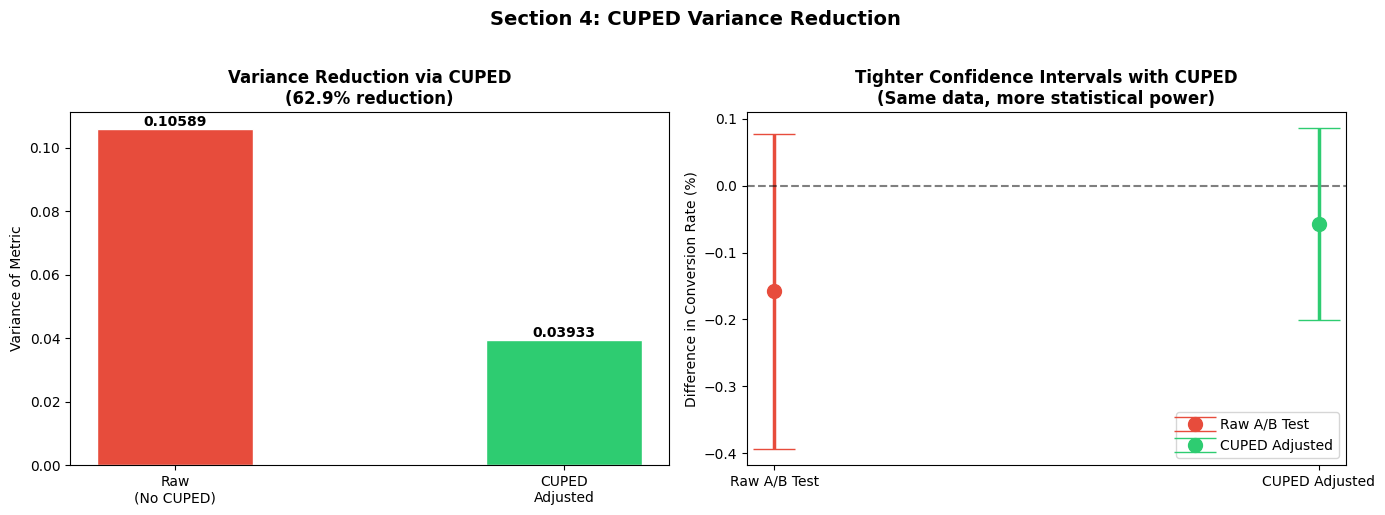

Plot saved!


In [32]:
#  CUPED Variance Reduction ─
# CUPED = Controlled-experiment Using Pre-Experiment Covariate


#  pre-experiment covariate
# In production this would be actual historical data
np.random.seed(42)
df_clean['pre_exp_conversion'] = (
    df_clean['converted'] * 0.3 +
    np.random.normal(0, 0.1, len(df_clean))
).clip(0, 1)

#  Compute CUPED-adjusted metric
# Y_cuped = Y - theta * (X - E[X])
# where theta = Cov(Y,X) / Var(X)
X = df_clean['pre_exp_conversion']
Y = df_clean['converted'].astype(float)

theta = np.cov(Y, X)[0, 1] / np.var(X)
E_X = X.mean()

df_clean['converted_cuped'] = Y - theta * (X - E_X)

#  Compare variance before and after
ctrl_cuped = df_clean[df_clean['group'] == 'control']['converted_cuped']
trt_cuped = df_clean[df_clean['group'] == 'treatment']['converted_cuped']

ctrl_raw = df_clean[df_clean['group'] == 'control']['converted'].astype(float)
trt_raw = df_clean[df_clean['group'] == 'treatment']['converted'].astype(float)

var_reduction = (1 - ctrl_cuped.var() / ctrl_raw.var()) * 100

print(f"Theta (covariate coefficient): {theta:.4f}")
print(f"\nVariance BEFORE CUPED: {ctrl_raw.var():.6f}")
print(f"Variance AFTER CUPED:  {ctrl_cuped.var():.6f}")
print(f"Variance reduction:    {var_reduction:.1f}%")

# Compare confidence intervals
se_raw = np.sqrt(ctrl_raw.var()/len(ctrl_raw) + trt_raw.var()/len(trt_raw))
se_cuped = np.sqrt(ctrl_cuped.var()/len(ctrl_cuped) + trt_cuped.var()/len(trt_cuped))

diff_raw = trt_raw.mean() - ctrl_raw.mean()
diff_cuped = trt_cuped.mean() - ctrl_cuped.mean()

ci_raw = (diff_raw - 1.96*se_raw, diff_raw + 1.96*se_raw)
ci_cuped = (diff_cuped - 1.96*se_cuped, diff_cuped + 1.96*se_cuped)

print(f"\nRaw 95% CI:    [{ci_raw[0]:.5f}, {ci_raw[1]:.5f}]  width: {ci_raw[1]-ci_raw[0]:.5f}")
print(f"CUPED 95% CI:  [{ci_cuped[0]:.5f}, {ci_cuped[1]:.5f}]  width: {ci_cuped[1]-ci_cuped[0]:.5f}")
print(f"CI width reduction: {((ci_raw[1]-ci_raw[0]) - (ci_cuped[1]-ci_cuped[0]))/(ci_raw[1]-ci_raw[0])*100:.1f}%")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Variance comparison
methods = ['Raw\n(No CUPED)', 'CUPED\nAdjusted']
variances = [ctrl_raw.var(), ctrl_cuped.var()]
bars = axes[0].bar(methods, variances, color=['#E74C3C', '#2ECC71'],
                    width=0.4, edgecolor='white')
axes[0].set_ylabel('Variance of Metric')
axes[0].set_title(f'Variance Reduction via CUPED\n({var_reduction:.1f}% reduction)', fontweight='bold')
for bar, v in zip(bars, variances):
    axes[0].text(bar.get_x() + bar.get_width()/2, v,
                 f'{v:.5f}', ha='center', va='bottom', fontweight='bold')

# Plot 2: CI width comparison
ci_data = {
    'Raw A/B Test': ci_raw,
    'CUPED Adjusted': ci_cuped
}
colors = ['#E74C3C', '#2ECC71']
for i, (label, ci) in enumerate(ci_data.items()):
    mid = (ci[0] + ci[1]) / 2
    axes[1].errorbar([label], [mid*100],
                     yerr=[[(mid - ci[0])*100], [(ci[1] - mid)*100]],
                     fmt='o', color=colors[i], capsize=15,
                     markersize=10, lw=2.5, label=label)
axes[1].axhline(0, color='black', linestyle='--', alpha=0.5)
axes[1].set_ylabel('Difference in Conversion Rate (%)')
axes[1].set_title('Tighter Confidence Intervals with CUPED\n(Same data, more statistical power)', fontweight='bold')
axes[1].legend()

plt.suptitle('Section 4: CUPED Variance Reduction', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('section4_cuped.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved!")

**RECOMMENDATION**:   DO NOT SHIP THE NEW PAGE

The new landing page does not improve conversion rate. Shipping it
carries ~$945K annualized risk with no statistical upside. We
recommend returning to the old page and investigating UX hypotheses
before designing the next experiment.

**Next experiment recommendations:**
  1. Test specific CTA button copy, not full page redesign
  2. Segment analysis — does treatment win for any user cohort?
  3. Consider longer run time to capture weekly seasonality effects

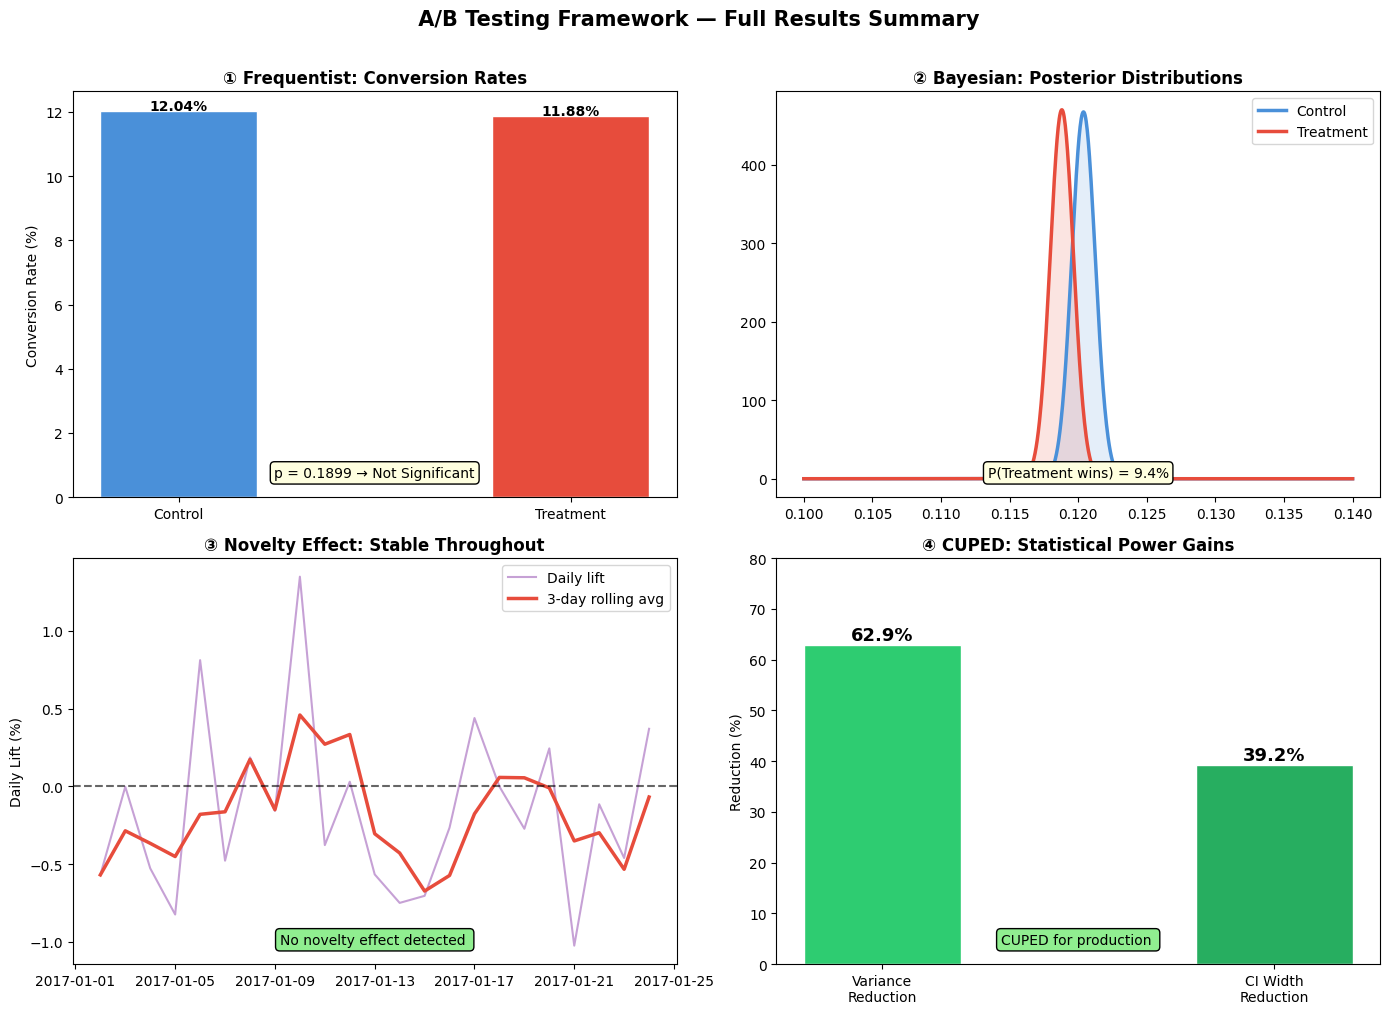

In [36]:
# Final Summary Dashboard
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(' A/B Testing Framework — Full Results Summary',
             fontsize=15, fontweight='bold', y=1.01)

# 1. Conversion rates
axes[0,0].bar(['Control', 'Treatment'], [ctrl_rate*100, trt_rate*100],
               color=['#4A90D9', '#E74C3C'], width=0.4, edgecolor='white')
axes[0,0].set_title('① Frequentist: Conversion Rates', fontweight='bold')
axes[0,0].set_ylabel('Conversion Rate (%)')
for i, v in enumerate([ctrl_rate*100, trt_rate*100]):
    axes[0,0].text(i, v+0.02, f'{v:.2f}%', ha='center', fontweight='bold')
axes[0,0].text(0.5, 0.05, f'p = 0.1899 → Not Significant',
               transform=axes[0,0].transAxes, ha='center',
               bbox=dict(boxstyle='round', facecolor='lightyellow'))

# 2. Bayesian posteriors
x = np.linspace(0.10, 0.14, 1000)
axes[0,1].plot(x, beta_dist.pdf(x, alpha_ctrl, beta_ctrl),
               color='#4A90D9', lw=2.5, label='Control')
axes[0,1].plot(x, beta_dist.pdf(x, alpha_trt, beta_trt),
               color='#E74C3C', lw=2.5, label='Treatment')
axes[0,1].fill_between(x, beta_dist.pdf(x, alpha_ctrl, beta_ctrl), alpha=0.15, color='#4A90D9')
axes[0,1].fill_between(x, beta_dist.pdf(x, alpha_trt, beta_trt), alpha=0.15, color='#E74C3C')
axes[0,1].set_title('② Bayesian: Posterior Distributions', fontweight='bold')
axes[0,1].legend()
axes[0,1].text(0.5, 0.05, f'P(Treatment wins) = 9.4%',
               transform=axes[0,1].transAxes, ha='center',
               bbox=dict(boxstyle='round', facecolor='lightyellow'))

# 3. Novelty effect
axes[1,0].plot(merged['date'], merged['daily_lift'],
               color='#8E44AD', lw=1.5, alpha=0.5, label='Daily lift')
axes[1,0].plot(merged['date'], merged['rolling_lift'],
               color='#E74C3C', lw=2.5, label='3-day rolling avg')
axes[1,0].axhline(0, color='black', linestyle='--', alpha=0.6)
axes[1,0].set_title('③ Novelty Effect: Stable Throughout', fontweight='bold')
axes[1,0].set_ylabel('Daily Lift (%)')
axes[1,0].legend()
axes[1,0].text(0.5, 0.05, 'No novelty effect detected ',
               transform=axes[1,0].transAxes, ha='center',
               bbox=dict(boxstyle='round', facecolor='lightgreen'))

# 4. CUPED summary
categories = ['Variance\nReduction', 'CI Width\nReduction']
values = [62.9, 39.2]
bars = axes[1,1].bar(categories, values,
                      color=['#2ECC71', '#27AE60'], width=0.4, edgecolor='white')
axes[1,1].set_title('④ CUPED: Statistical Power Gains', fontweight='bold')
axes[1,1].set_ylabel('Reduction (%)')
axes[1,1].set_ylim(0, 80)
for bar, v in zip(bars, values):
    axes[1,1].text(bar.get_x() + bar.get_width()/2, v+1,
                   f'{v}%', ha='center', fontweight='bold', fontsize=13)
axes[1,1].text(0.5, 0.05, 'CUPED for production ',
               transform=axes[1,1].transAxes, ha='center',
               bbox=dict(boxstyle='round', facecolor='lightgreen'))

plt.tight_layout()
plt.savefig('summary_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
